# BigEarthNet-S2 Dataset Exploration
Visualización y análisis del dataset antes de entrenar el modelo.

In [2]:
import sys
sys.path.insert(0, '..')

from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

from src.data.dataset import CLASSES

In [3]:
DATASET_ROOT = Path("/media/alejandro/SSD/datasets/bigearthnet/BigEarthNet-S2")
METADATA_PATH = "/media/alejandro/SSD/datasets/bigearthnet/metadata.parquet"

df = pd.read_parquet(METADATA_PATH)
print(f"Total patches: {len(df)}")
print(f"\nDistribución de splits:")
print(df['split'].value_counts())

Total patches: 480038

Distribución de splits:
split
train         237871
validation    122342
test          119825
Name: count, dtype: int64


## 1. Distribución de clases

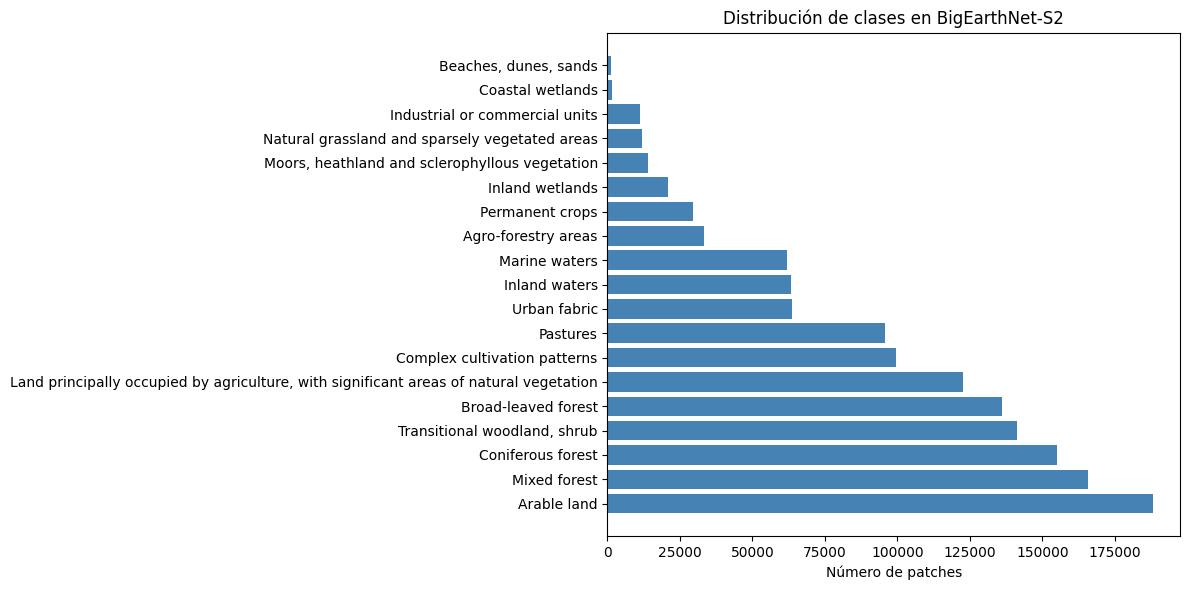

In [4]:
class_counts = Counter()
for labels in df['labels']:
    for label in labels:
        class_counts[label] += 1

sorted_classes = sorted(class_counts.items(), key=lambda x: -x[1])
labels_names, counts = zip(*sorted_classes)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(labels_names, counts, color='steelblue')
ax.set_xlabel('Número de patches')
ax.set_title('Distribución de clases en BigEarthNet-S2')
plt.tight_layout()
plt.show()

## 2. Número de etiquetas por patch

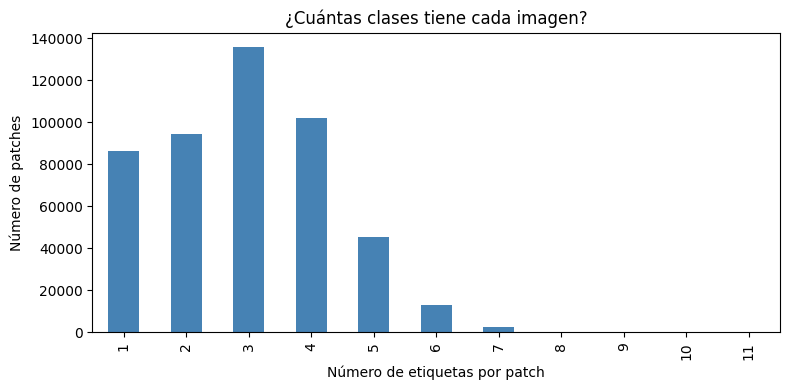

Media de etiquetas por patch: 2.95


In [5]:
df['num_labels'] = df['labels'].apply(len)

fig, ax = plt.subplots(figsize=(8, 4))
df['num_labels'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Número de etiquetas por patch')
ax.set_ylabel('Número de patches')
ax.set_title('¿Cuántas clases tiene cada imagen?')
plt.tight_layout()
plt.show()

print(f"Media de etiquetas por patch: {df['num_labels'].mean():.2f}")

## 3. Visualización de imágenes de ejemplo

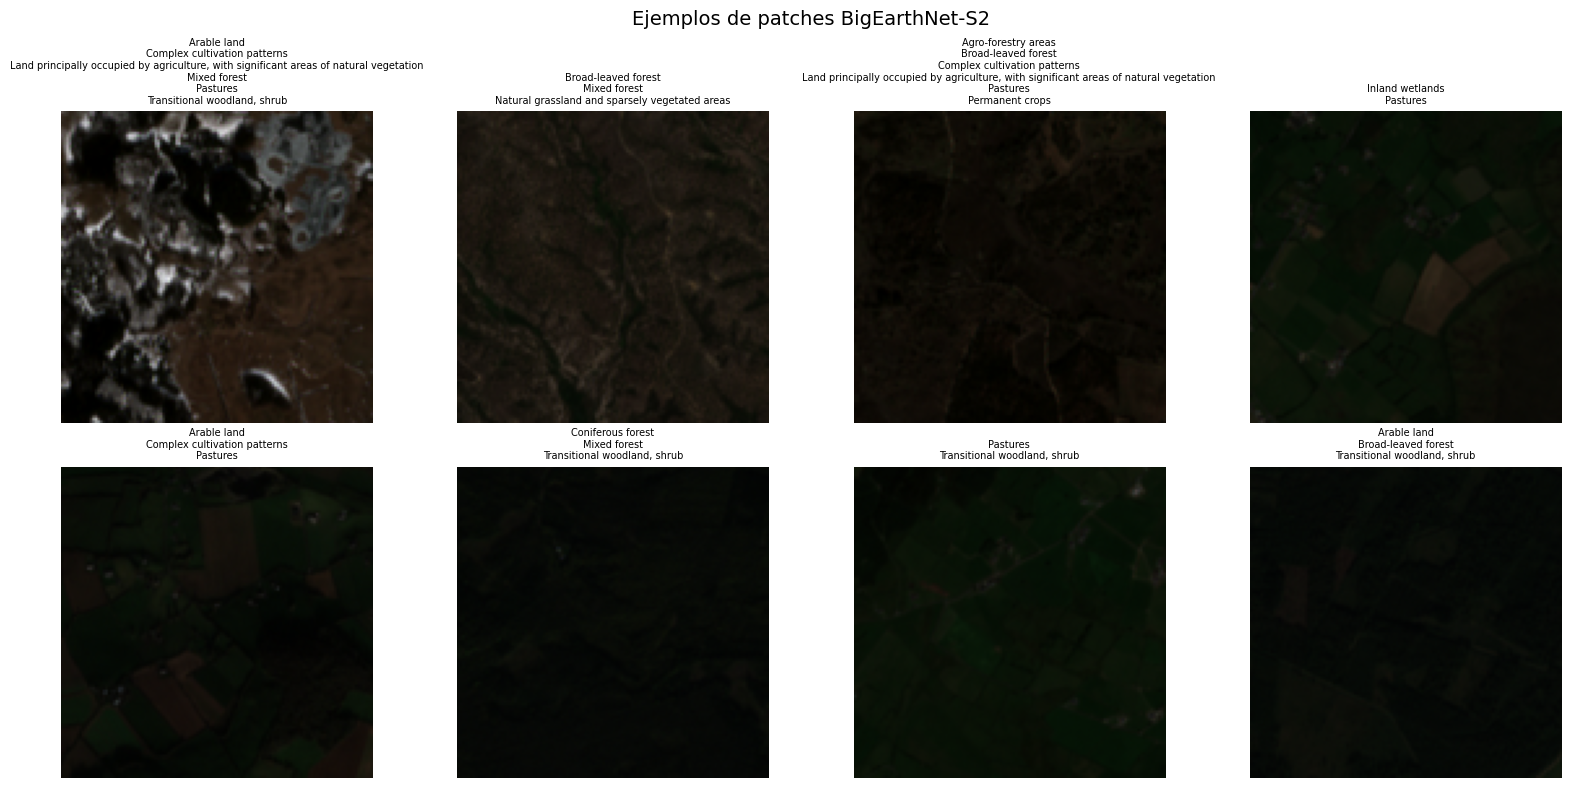

In [6]:
def load_rgb(patch_id: str) -> np.ndarray:
    """Carga bandas B04, B03, B02 como imagen RGB."""
    scene_id = "_".join(patch_id.rsplit("_", 2)[:-2])
    patch_dir = DATASET_ROOT / scene_id / patch_id
    bands = []
    for band in ["B04", "B03", "B02"]:
        tif_path = patch_dir / f"{patch_id}_{band}.tif"
        with rasterio.open(tif_path) as src:
            bands.append(src.read(1).astype(np.float32))
    image = np.stack(bands, axis=-1)
    image = image / 10000.0
    return np.clip(image, 0, 1)


sample = df.sample(8, random_state=42)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    image = load_rgb(row['patch_id'])
    ax.imshow(image)
    ax.set_title("\n".join(row['labels']), fontsize=7)
    ax.axis('off')

plt.suptitle('Ejemplos de patches BigEarthNet-S2', fontsize=14)
plt.tight_layout()
plt.show()